# Adult 데이터 전처리 전체 실험 과정

**판교 8반 정승원**

이 노트북은 Adult Census Income 데이터의 전처리 전 과정을 하나의 흐름으로 재현한다.
결측 메커니즘 진단부터 완전제거·중앙값/최빈값·kNN·MICE 비교, 중복·극단값 민감도,
최종 모델 Pipeline까지 연결하고, 마지막에 공유용 **결측행 완전제거(train/test 분리)**
데이터를 생성한다.

노트북에서 구분하는 네 가지 데이터는 다음과 같다.

1. **진단**: 실제 결측이 무작위인지 확인하고 삭제·대체 판단의 근거를 만든다.
2. **후보 실험**: 완전제거, 중앙값·최빈값, kNN, MICE를 같은 마스크로 비교한다.
3. **최종 모델 전처리**: 원본 행을 유지하고 Pipeline 내부에서 중앙값·최빈값 대체 후 인코딩한다.
4. **이번 공유본**: 결측값이 하나라도 있는 행을 삭제한 complete-case train/test 데이터다.

> 네 가지는 목적과 표본이 다르므로 같은 데이터로 오해하면 안 된다.

## 0. 실행 환경

이 노트북은 **독립 실행형**이다 (`AGENTS.md` 1절 규칙). `src/`를 import하지 않고 필요한
상수·함수를 노트북 안에 직접 담았으므로, 이 파일 하나만으로 처음부터 끝까지 실행된다.
탐색이 먼저이고 모듈화가 그 뒤이므로, 탐색 노트북이 결과물인 `src/`에 의존하지 않는 편이
순서에 맞다.

실행 방법은 저장소 루트에서 다음과 같다.

```bash
uv run jupyter lab notebooks/preprocessing.ipynb
```

원본 데이터(`data/adult.data`, `data/adult.test`)가 없으면 아래 첫 코드 셀이 UCI에서
내려받아 캐시한다. 이미 있으면 네트워크를 쓰지 않는다.

차트는 노트북에 바로 표시되고 동시에 `outputs/figures/*.png`로도 저장된다.
한글 라벨을 쓰므로 설치된 한글 폰트(AppleGothic / NanumGothic 등)를 자동으로 찾아 지정한다.

In [1]:
from __future__ import annotations

import hashlib
import urllib.error
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.compose import ColumnTransformer

# noqa: F401 — import 자체가 IterativeImputer를 활성화한다.
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# 차트를 노트북 안에 이미지로 embed한다.
%matplotlib inline

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

# 순서 주의: set_theme가 font.family를 되돌려놓으므로 반드시 먼저 호출하고
# 그 뒤에 한글 폰트를 지정해야 한다. 반대로 하면 라벨이 네모(두부)로 깨진다.
sns.set_theme(style="whitegrid")

INSTALLED_FONTS = {f.name for f in font_manager.fontManager.ttflist}
KOREAN_FONT = next(
    (f for f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic")
     if f in INSTALLED_FONTS),
    None,
)
if KOREAN_FONT is None:
    print("[warn] 한글 폰트를 찾지 못했습니다. 차트의 한글 라벨이 깨질 수 있습니다.")
else:
    plt.rcParams["font.family"] = KOREAN_FONT
plt.rcParams["axes.unicode_minus"] = False  # 한글 폰트는 유니코드 음수 기호가 깨진다.
plt.rcParams["figure.dpi"] = 110

# 노트북은 notebooks/ 안에 있으므로 한 단계 위가 프로젝트 루트다.
# jupyter를 루트에서 실행하는 경우까지 감안해 data/가 있는 쪽을 찾는다.
CWD = Path.cwd().resolve()
ROOT = next((p for p in [CWD, *CWD.parents] if (p / "data").exists()), CWD)

DATA_DIR = ROOT / "data"
OUTPUT_DIR = ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"  # 차트는 노트북에 표시하고 파일로도 남긴다.
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_RAW_PATH = DATA_DIR / "adult.data"
TEST_RAW_PATH = DATA_DIR / "adult.test"

BASE_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult"
SEED = 42

# 원본 파일에 헤더가 없으므로 공식 15개 컬럼명을 직접 지정한다.
COLS: list[str] = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income",
]
# 결측은 원본에 " ?"(앞 공백 포함)로 기록되어 있다. pandas 3.x는 skipinitialspace로
# 공백을 먼저 제거한 뒤 결측을 매칭하므로 두 형태를 모두 등록한다.
NA_VALUES: list[str] = ["?", " ?"]


# --------------------------------------------------
# 함수명 : show_figure
# 목적   : 차트를 outputs/figures에 저장하고 노트북에 표시
# 매개변수: fig(plt.Figure) - 대상 그림 / name(str) - 확장자 없는 파일명
# 반환값 : None
# --------------------------------------------------
def show_figure(fig: plt.Figure, name: str) -> None:
    fig.tight_layout()
    try:
        fig.savefig(FIGURE_DIR / f"{name}.png", dpi=120, bbox_inches="tight")
    except OSError as exc:
        # 저장에 실패해도 화면 표시는 계속한다.
        print(f"[warn] {name}.png 저장 실패: {exc}")
    plt.show()


print("ROOT:", ROOT)
print("figures:", FIGURE_DIR)

ROOT: /Users/donghyeon/skala-workspace/week4/team-analysis
figures: /Users/donghyeon/skala-workspace/week4/team-analysis/outputs/figures


## 1. 원본 파일 로딩

UCI Adult 원본은 일반 CSV처럼 바로 읽으면 안 된다. 다음 규칙을 적용한다.

1. 헤더가 없으므로 `COLS`의 공식 15개 컬럼명을 부여한다.
2. 쉼표 뒤의 선행 공백을 제거한다.
3. 문자열 `?`를 실제 결측값 `NaN`으로 변환한다.
4. `adult.test` 첫 줄의 메타데이터 줄을 건너뛴다.
5. test 라벨의 마침표를 제거한다: `>50K.` → `>50K`, `<=50K.` → `<=50K`.

이 단계에서는 아직 행 삭제, 결측 대체, 표준화, 인코딩을 하지 않는다.

In [2]:
# --------------------------------------------------
# 함수명 : ensure_raw_file
# 목적   : 원본 파일이 없으면 UCI에서 내려받아 캐시
# 매개변수: path(Path) - 캐시 경로
# 반환값 : Path - 사용 가능한 원본 파일 경로
# --------------------------------------------------
def ensure_raw_file(path: Path) -> Path:
    if path.exists():
        return path
    path.parent.mkdir(parents=True, exist_ok=True)
    url = f"{BASE_URL}/{path.name}"
    try:
        with urllib.request.urlopen(url, timeout=60) as response:
            payload = response.read()
    except (urllib.error.URLError, TimeoutError) as exc:
        raise RuntimeError(f"{url} 다운로드 실패 — 네트워크를 확인하세요: {exc}") from exc
    path.write_bytes(payload)
    return path


# --------------------------------------------------
# 함수명 : load_raw
# 목적   : Adult 원본 파일을 프로젝트 규칙대로 파싱
# 매개변수: path(Path) - 원본 파일 경로 / is_test(bool) - adult.test 여부
# 반환값 : pd.DataFrame - 결측이 NaN으로 표기된 15컬럼 원본
# --------------------------------------------------
def load_raw(path: Path, is_test: bool = False) -> pd.DataFrame:
    try:
        frame = pd.read_csv(
            ensure_raw_file(path),
            header=None,
            names=COLS,
            skipinitialspace=True,
            na_values=NA_VALUES,
            skiprows=1 if is_test else 0,  # adult.test 첫 줄은 데이터가 아닌 메타데이터다.
        )
    except (FileNotFoundError, pd.errors.ParserError) as exc:
        raise RuntimeError(f"{path} 파싱 실패: {exc}") from exc
    if is_test:
        # test 라벨만 마침표가 붙어 있어 train과 라벨 집합이 달라진다.
        frame["income"] = frame["income"].str.rstrip(".")
    return frame


train_raw = load_raw(TRAIN_RAW_PATH)
test_raw = load_raw(TEST_RAW_PATH, is_test=True)

load_summary = pd.DataFrame({
    "split": ["train", "test"],
    "rows": [len(train_raw), len(test_raw)],
    "columns": [train_raw.shape[1], test_raw.shape[1]],
    "missing_cells": [int(train_raw.isna().sum().sum()), int(test_raw.isna().sum().sum())],
    "rows_with_missing": [
        int(train_raw.isna().any(axis=1).sum()),
        int(test_raw.isna().any(axis=1).sum()),
    ],
})
load_summary

,split,rows,columns,missing_cells,rows_with_missing
0,train,32561,15,4262,2399
1,test,16281,15,2203,1221


In [3]:
assert train_raw.shape == (32561, 15)
assert test_raw.shape == (16281, 15)
assert list(train_raw.columns) == COLS == list(test_raw.columns)
assert set(train_raw["income"]) == {"<=50K", ">50K"}
assert set(test_raw["income"]) == {"<=50K", ">50K"}
train_raw.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2. 결측 구조 확인

결측은 `workclass`, `occupation`, `native-country` 세 컬럼에만 있으며,
`workclass`와 `occupation`은 대부분 **함께** 비어 있다. 즉 서로 독립적인 결측이 아니라
같은 응답 실패에서 나온 구조적 결측에 가깝다.

In [4]:
# --------------------------------------------------
# 함수명 : missing_table
# 목적   : 결측이 있는 컬럼만 골라 개수·비율 표로 정리
# 매개변수: df(pd.DataFrame) - 대상 데이터 / split(str) - 표에 남길 split 이름
# 반환값 : pd.DataFrame - 컬럼별 결측 개수·비율
# --------------------------------------------------
def missing_table(df: pd.DataFrame, split: str) -> pd.DataFrame:
    counts = df.isna().sum()
    result = pd.DataFrame({
        "split": split,
        "column": counts.index,
        "missing_count": counts.to_numpy(),
        "missing_pct": (counts.to_numpy() / len(df) * 100).round(2),
    })
    return result[result["missing_count"] > 0].reset_index(drop=True)


missing_by_column = pd.concat([
    missing_table(train_raw, "train"),
    missing_table(test_raw, "test"),
], ignore_index=True)
missing_by_column

,split,column,missing_count,missing_pct
0,train,workclass,1836,5.64
1,train,occupation,1843,5.66
2,train,native-country,583,1.79
3,test,workclass,963,5.91
4,test,occupation,966,5.93
5,test,native-country,274,1.68


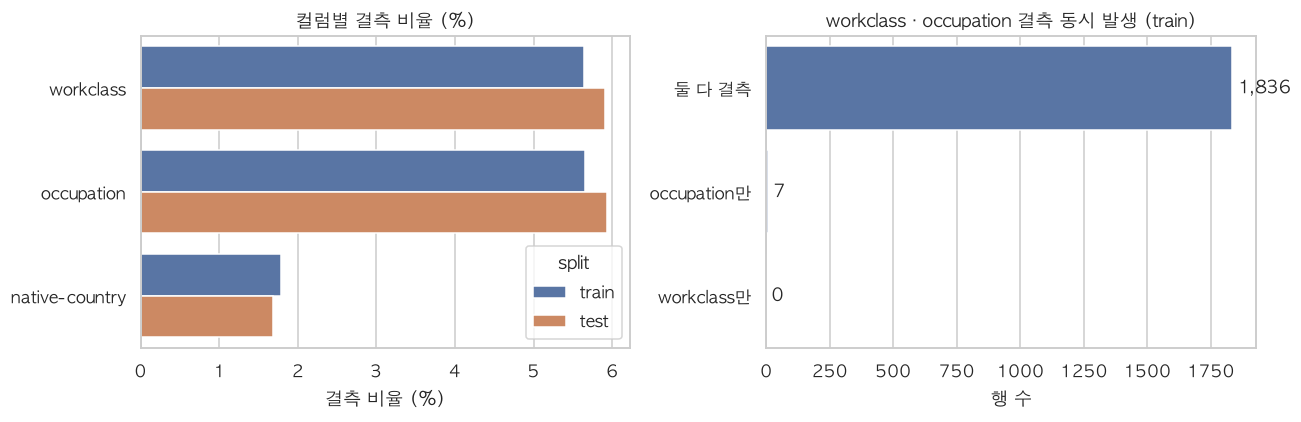

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(missing_by_column, x="missing_pct", y="column", hue="split", ax=axes[0])
axes[0].set_title("컬럼별 결측 비율 (%)")
axes[0].set_xlabel("결측 비율 (%)")
axes[0].set_ylabel("")

# workclass/occupation이 따로 비는지 같이 비는지를 눈으로 확인한다.
workclass_na = train_raw["workclass"].isna()
occupation_na = train_raw["occupation"].isna()
overlap = pd.Series({
    "둘 다 결측": int((workclass_na & occupation_na).sum()),
    "occupation만": int((~workclass_na & occupation_na).sum()),
    "workclass만": int((workclass_na & ~occupation_na).sum()),
})
sns.barplot(x=overlap.to_numpy(), y=overlap.index.to_numpy(), ax=axes[1], color="#4C72B0")
axes[1].set_title("workclass · occupation 결측 동시 발생 (train)")
axes[1].set_xlabel("행 수")
for i, value in enumerate(overlap.to_numpy()):
    axes[1].text(value + 20, i, f"{value:,}", va="center")

show_figure(fig, "01_missing_structure")

In [6]:
# --------------------------------------------------
# 함수명 : missing_profile
# 목적   : 행 단위 결측 규모와 workclass/occupation 동시 결측 구조를 요약
# 매개변수: df(pd.DataFrame) - 대상 데이터
# 반환값 : dict[str, int] - 결측 진단 요약값
# --------------------------------------------------
def missing_profile(df: pd.DataFrame) -> dict[str, int]:
    workclass_na = df["workclass"].isna()
    occupation_na = df["occupation"].isna()
    return {
        "rows": len(df),
        "rows_with_any_missing": int(df.isna().any(axis=1).sum()),
        "workclass_missing": int(workclass_na.sum()),
        "occupation_missing": int(occupation_na.sum()),
        "workclass_occupation_both_missing": int((workclass_na & occupation_na).sum()),
        "occupation_only_missing": int((~workclass_na & occupation_na).sum()),
        "native_country_missing": int(df["native-country"].isna().sum()),
    }


report_missing = missing_profile(train_raw)
assert report_missing["rows_with_any_missing"] == 2399
assert report_missing["workclass_occupation_both_missing"] == 1836
pd.Series(report_missing, name="train 결측 진단")

rows                                 32561
rows_with_any_missing                 2399
workclass_missing                     1836
occupation_missing                    1843
workclass_occupation_both_missing     1836
occupation_only_missing                  7
native_country_missing                 583
Name: train 결측 진단, dtype: int64

## 3. 결측 메커니즘 진단 (H3)

결측이 완전 무작위(MCAR)라면, **관측된 다른 변수로 결측 여부를 예측할 수 없어야** 한다.
그래서 `occupation` 결측 지시자를 타깃으로 두고 나머지 관측 변수만으로 로지스틱 회귀를
교차검증했다. AUC가 0.5 근처면 MCAR과 양립하고, 뚜렷하게 높으면 MCAR로 보기 어렵다.

`fnlwgt`는 모델 피처에서 제외하는 변수지만 여기서는 **진단 목적**이므로 포함한다.
결측 여부가 어떤 관측 정보로든 설명되는지를 보는 것이 목적이기 때문이다.

In [7]:
# --------------------------------------------------
# 함수명 : diagnose_missingness
# 목적   : occupation 결측 여부를 관측 변수로 예측해 MCAR 가정을 검증
# 매개변수: df(pd.DataFrame) - 원본 데이터
# 반환값 : dict[str, float] - 교차검증 AUC와 결측 비율
# --------------------------------------------------
def diagnose_missingness(df: pd.DataFrame) -> dict[str, float]:
    target = df["occupation"].isna().astype(int)
    # 결측이 있는 컬럼(workclass, occupation, native-country)은 설명변수에서 제외한다.
    observed = [c for c in COLS if c not in {"workclass", "occupation", "native-country"}]
    numeric = list(df[observed].select_dtypes(include="number").columns)
    categorical = [c for c in observed if c not in numeric]

    model = Pipeline([
        ("prep", ColumnTransformer([
            ("num", StandardScaler(), numeric),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ])),
        ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
    ])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = cross_val_score(model, df[observed], target, cv=cv, scoring="roc_auc")
    return {
        "missing_rate": float(target.mean()),
        "cv_auc_mean": float(scores.mean()),
        "cv_auc_sd": float(scores.std(ddof=1)),
    }


missingness_diagnosis = diagnose_missingness(train_raw)
# AUC가 0.5를 뚜렷하게 넘으면 결측을 완전 무작위로 볼 수 없다.
assert missingness_diagnosis["cv_auc_mean"] > 0.6
pd.Series(missingness_diagnosis, name="occupation 결측 예측").round(4)

missing_rate    0.0566
cv_auc_mean     0.7460
cv_auc_sd       0.0144
Name: occupation 결측 예측, dtype: float64

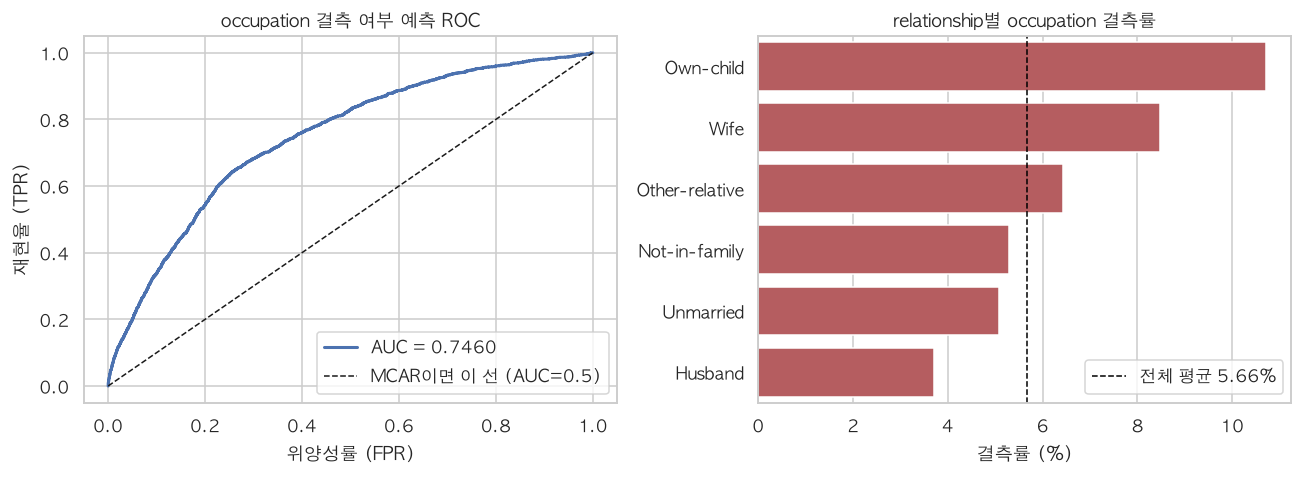

In [8]:
# 위 AUC를 곡선으로 확인한다. 대각선(랜덤 추측)에서 멀수록 MCAR과 멀어진다.
diag_target = train_raw["occupation"].isna().astype(int)
diag_observed = [c for c in COLS if c not in {"workclass", "occupation", "native-country"}]
diag_numeric = list(train_raw[diag_observed].select_dtypes(include="number").columns)
diag_categorical = [c for c in diag_observed if c not in diag_numeric]

diag_model = Pipeline([
    ("prep", ColumnTransformer([
        ("num", StandardScaler(), diag_numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), diag_categorical),
    ])),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
])
diag_proba = cross_val_predict(
    diag_model, train_raw[diag_observed], diag_target,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    method="predict_proba",
)[:, 1]
fpr, tpr, _ = roc_curve(diag_target, diag_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(fpr, tpr, lw=2,
             label=f"AUC = {missingness_diagnosis['cv_auc_mean']:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="MCAR이면 이 선 (AUC=0.5)")
axes[0].set_title("occupation 결측 여부 예측 ROC")
axes[0].set_xlabel("위양성률 (FPR)")
axes[0].set_ylabel("재현율 (TPR)")
axes[0].legend(loc="lower right")

# 어떤 집단에서 결측이 몰리는지 본다. 결측이 특정 집단에 쏠리면 MCAR이 아니다.
by_group = (
    train_raw.groupby("relationship", observed=True)["occupation"]
    .apply(lambda s: s.isna().mean() * 100)
    .sort_values(ascending=False)
)
sns.barplot(x=by_group.to_numpy(), y=by_group.index.to_numpy(), ax=axes[1], color="#C44E52")
axes[1].axvline(diag_target.mean() * 100, color="black", ls="--", lw=1,
                label=f"전체 평균 {diag_target.mean() * 100:.2f}%")
axes[1].set_title("relationship별 occupation 결측률")
axes[1].set_xlabel("결측률 (%)")
axes[1].legend()

show_figure(fig, "02_missingness_diagnosis")

AUC가 0.5를 크게 웃돈다. 즉 **결측 여부가 관측 변수로 상당 부분 예측된다.**
따라서 MCAR 가정은 지지되지 않고, 결측행을 그냥 지우면 선택 편향이 생길 수 있다.
이것이 뒤에서 완전제거본을 "공유용 산출물"로만 쓰고 주 모델에는 쓰지 않는 이유다.

## 4. 결측 처리 후보를 비교한 실험 설계

실제 결측 셀은 정답을 알 수 없으므로 대체 정확도를 직접 채점할 수 없다. 따라서 결측이 없는
행에서 8,000행을 소득 비율을 유지하며 뽑고, 6,000행은 대체기 학습용, 2,000행은 손대지 않는
홀드아웃으로 나눈다. 홀드아웃은 **정답이 보존된 채로** downstream 평가에만 쓴다.

마스킹 대상은 `age`, `hours-per-week`, `workclass`, `occupation` 네 컬럼이고 목표 결측률은
약 15%다.

- **MCAR**: 학습 영역의 각 대상 셀을 같은 확률로 삭제
- **MAR 모사**: `education-num`과 `capital-gain>0`에 따라 삭제 확률이 달라지게 생성
- 반복: 시드를 바꾼 마스크 `N_REPS`회
- 누수 방지: 모든 대체기의 통계량·모형은 6,000개 학습 행에서만 적합

평가는 수치형 표준화 RMSE(낮을수록 좋음), 범주형 오분류율(낮을수록 좋음),
원본 홀드아웃 downstream F1(높을수록 좋음)으로 나눈다.

In [9]:
BENCH_NUM = ["age", "hours-per-week"]
BENCH_CAT = ["workclass", "occupation"]
BENCH_TARGETS = BENCH_NUM + BENCH_CAT
# 대체기·downstream 모델이 함께 참고하는 보조 변수 (마스킹하지 않는다)
AUX_NUM = ["education-num", "capital-gain", "capital-loss", "fnlwgt"]
AUX_CAT = ["marital-status", "relationship", "race", "sex"]
BENCH_NUM_ALL = BENCH_NUM + AUX_NUM
BENCH_CAT_ALL = BENCH_CAT + AUX_CAT
BENCH_ALL = BENCH_NUM_ALL + BENCH_CAT_ALL

BENCH_SCENARIOS = ["MCAR", "MAR"]
MASK_RATE = 0.15
N_REPS = 5


# --------------------------------------------------
# 함수명 : build_sample
# 목적   : 결측 없는 행에서 실험용 표본과 학습/홀드아웃 인덱스를 구성
# 매개변수: df(pd.DataFrame) - 원본 / n_sample(int) - 표본 크기 / n_train(int) - 대체기 학습 행 수
# 반환값 : tuple[pd.DataFrame, np.ndarray, np.ndarray] - 표본, 학습 인덱스, 홀드아웃 인덱스
# --------------------------------------------------
def build_sample(
    df: pd.DataFrame, n_sample: int = 8000, n_train: int = 6000
) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    complete = df.dropna(axis=0, how="any").reset_index(drop=True)
    sample, _ = train_test_split(
        complete, train_size=n_sample, random_state=SEED, stratify=complete["income"]
    )
    sample = sample.reset_index(drop=True)
    train_idx, holdout_idx = train_test_split(
        np.arange(n_sample), train_size=n_train, random_state=SEED,
        stratify=sample["income"],
    )
    return sample, np.sort(train_idx), np.sort(holdout_idx)


# --------------------------------------------------
# 함수명 : make_masks
# 목적   : MCAR·MAR 두 시나리오의 결측 마스크를 학습 영역에만 생성
# 매개변수: sample(pd.DataFrame) - 실험 표본 / train_idx(np.ndarray) - 학습 인덱스
#           seed(int) - 난수 시드
# 반환값 : dict[str, pd.DataFrame] - 시나리오별 불리언 마스크
# --------------------------------------------------
def make_masks(
    sample: pd.DataFrame, train_idx: np.ndarray, seed: int = SEED
) -> dict[str, pd.DataFrame]:
    rng = np.random.default_rng(seed)
    masks: dict[str, pd.DataFrame] = {}
    for scenario in BENCH_SCENARIOS:
        mask = pd.DataFrame(False, index=sample.index, columns=BENCH_TARGETS)
        if scenario == "MCAR":
            prob = np.full(len(train_idx), MASK_RATE)
        else:
            # MAR: 관측 변수(교육연수, 자본이득 유무)에 따라 삭제 확률이 달라진다.
            edu = sample.loc[train_idx, "education-num"]
            logit = 0.35 * ((edu - edu.mean()) / edu.std()).to_numpy()
            logit += 0.8 * (sample.loc[train_idx, "capital-gain"] > 0).to_numpy(dtype=float)
            base = np.log(MASK_RATE / (1 - MASK_RATE))
            prob = 1 / (1 + np.exp(-(base + logit - logit.mean())))
        draws = rng.random((len(train_idx), len(BENCH_TARGETS)))
        mask.loc[train_idx, BENCH_TARGETS] = draws < prob[:, None]
        masks[scenario] = mask
    return masks


bench_sample, bench_train_idx, bench_holdout_idx = build_sample(train_raw)
rep0_masks = make_masks(bench_sample, bench_train_idx, seed=SEED)

mask_design = pd.DataFrame([{
    "scenario": scenario,
    "sample_rows": len(bench_sample),
    "imputer_train_rows": len(bench_train_idx),
    "untouched_holdout_rows": len(bench_holdout_idx),
    "masked_cells": int(mask.to_numpy().sum()),
    "actual_mask_rate_train_pct": round(
        mask.loc[bench_train_idx].to_numpy().mean() * 100, 2
    ),
    "holdout_masked_cells": int(mask.loc[bench_holdout_idx].to_numpy().sum()),
} for scenario, mask in rep0_masks.items()])

# 홀드아웃은 절대 마스킹되지 않아야 downstream 평가가 공정하다.
assert (mask_design["holdout_masked_cells"] == 0).all()
mask_design

,scenario,sample_rows,imputer_train_rows,untouched_holdout_rows,masked_cells,actual_mask_rate_train_pct,holdout_masked_cells
0,MCAR,8000,6000,2000,3583,14.93,0
1,MAR,8000,6000,2000,3777,15.74,0


## 5. 고전 결측 처리 방법을 같은 마스크에서 직접 비교

비교하는 방법은 다음 네 가지다.

- **완전제거법**: 대상 셀 중 하나라도 지워진 학습 행을 아예 사용하지 않음
- **SimpleImputer**: 수치형 중앙값, 범주형 최빈값
- **kNNImputer(k=5)**: 가까운 관측치의 정보를 이용
- **MICE 근사**: `IterativeImputer`로 각 변수를 다른 변수의 함수로 반복 예측

sklearn kNN·MICE는 범주형을 직접 다루지 못하므로 범주를 서수 코드로 바꾼 뒤 대체하고
반올림해 되돌린다. 따라서 범주형 오분류율에는 **이 근사의 한계도 함께 포함**되어 있다.

In [10]:
# --------------------------------------------------
# 함수명 : apply_mask
# 목적   : 마스크가 True인 셀을 NaN으로 바꾼 사본 생성
# 매개변수: sample(pd.DataFrame) - 정답 표본 / mask(pd.DataFrame) - 불리언 마스크
# 반환값 : pd.DataFrame - 인위적 결측이 들어간 데이터
# --------------------------------------------------
def apply_mask(sample: pd.DataFrame, mask: pd.DataFrame) -> pd.DataFrame:
    masked = sample.copy()
    for col in BENCH_TARGETS:
        masked.loc[mask[col].to_numpy(), col] = np.nan
    return masked


# --------------------------------------------------
# 함수명 : impute_simple
# 목적   : 학습 행 통계만으로 중앙값·최빈값 대체
# 매개변수: masked(pd.DataFrame) - 결측 데이터 / train_idx(np.ndarray) - 통계 산출 행
# 반환값 : pd.DataFrame - 대체 완료 데이터
# --------------------------------------------------
def impute_simple(masked: pd.DataFrame, train_idx: np.ndarray) -> pd.DataFrame:
    out = masked.copy()
    for col in BENCH_NUM:
        out[col] = out[col].fillna(masked.loc[train_idx, col].median())
    for col in BENCH_CAT:
        out[col] = out[col].fillna(masked.loc[train_idx, col].mode().iloc[0])
    return out


# --------------------------------------------------
# 함수명 : impute_matrix
# 목적   : 범주를 서수 코드로 바꾼 행렬에 kNN/MICE 대체기를 적용하고 범주를 되돌림
# 매개변수: masked(pd.DataFrame) - 결측 데이터 / train_idx(np.ndarray) - 적합 행
#           imputer - sklearn 대체기
# 반환값 : pd.DataFrame - 대체 완료 데이터
# --------------------------------------------------
def impute_matrix(
    masked: pd.DataFrame, train_idx: np.ndarray, imputer: KNNImputer | IterativeImputer
) -> pd.DataFrame:
    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    codes = encoder.fit_transform(masked[BENCH_CAT_ALL])
    matrix = np.column_stack([masked[BENCH_NUM_ALL].to_numpy(dtype=float), codes])

    imputer.fit(matrix[train_idx])  # 누수 방지: 학습 행에서만 적합
    filled = imputer.transform(matrix)

    out = masked.copy()
    for col in BENCH_NUM:
        out[col] = filled[:, BENCH_NUM_ALL.index(col)]

    decoded = filled[:, len(BENCH_NUM_ALL):].copy()
    # 서수 코드는 연속값으로 채워지므로 반올림해 유효 범주 범위로 되돌린다.
    for i, categories in enumerate(encoder.categories_):
        decoded[:, i] = np.clip(np.rint(decoded[:, i]), 0, len(categories) - 1)
    labels = encoder.inverse_transform(decoded)
    for col in BENCH_CAT:
        out[col] = labels[:, BENCH_CAT_ALL.index(col)]
    return out


# --------------------------------------------------
# 함수명 : score_imputation
# 목적   : 마스킹된 셀만 대상으로 수치 RMSE와 범주 오분류율 계산
# 매개변수: imputed(pd.DataFrame) - 대체 결과 / truth(pd.DataFrame) - 정답
#           mask(pd.DataFrame) - 마스크
# 반환값 : tuple[float, float] - (표준화 RMSE, 범주 오분류율)
# --------------------------------------------------
def score_imputation(
    imputed: pd.DataFrame, truth: pd.DataFrame, mask: pd.DataFrame
) -> tuple[float, float]:
    # 스케일이 다른 컬럼을 함께 평균 내야 하므로 정답 표준편차로 나눠 표준화한다.
    squared = np.concatenate([
        (((imputed.loc[mask[c].to_numpy(), c] - truth.loc[mask[c].to_numpy(), c])
          / truth[c].std()) ** 2).to_numpy()
        for c in BENCH_NUM if mask[c].any()
    ])
    wrong = np.concatenate([
        (imputed.loc[mask[c].to_numpy(), c] != truth.loc[mask[c].to_numpy(), c]).to_numpy()
        for c in BENCH_CAT if mask[c].any()
    ])
    return float(np.sqrt(squared.mean())), float(wrong.mean())


# --------------------------------------------------
# 함수명 : downstream_f1
# 목적   : 대체 결과로 학습한 모델을 손대지 않은 홀드아웃에서 F1로 평가
# 매개변수: frame(pd.DataFrame) - 학습에 쓸 데이터 / truth(pd.DataFrame) - 정답 표본
#           train_idx(np.ndarray) - 학습 행 / holdout_idx(np.ndarray) - 평가 행
# 반환값 : float - >50K 클래스의 F1
# --------------------------------------------------
def downstream_f1(
    frame: pd.DataFrame, truth: pd.DataFrame, train_idx: np.ndarray, holdout_idx: np.ndarray
) -> float:
    model = Pipeline([
        ("prep", ColumnTransformer([
            ("num", StandardScaler(), BENCH_NUM_ALL),
            ("cat", OneHotEncoder(handle_unknown="ignore"), BENCH_CAT_ALL),
        ])),
        ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
    ])
    y = (truth["income"] == ">50K").astype(int)
    model.fit(frame.loc[train_idx, BENCH_ALL], y.loc[train_idx])
    # 평가는 항상 마스킹되지 않은 원본 홀드아웃으로 한다.
    pred = model.predict(truth.loc[holdout_idx, BENCH_ALL])
    return float(f1_score(y.loc[holdout_idx], pred))

In [11]:
bench_rows: list[dict[str, object]] = []
for rep in range(N_REPS):
    masks = make_masks(bench_sample, bench_train_idx, seed=SEED + rep)
    for scenario, mask in masks.items():
        masked = apply_mask(bench_sample, mask)

        # 완전제거: 대상 셀이 하나라도 지워진 학습 행을 버린다. 복원 지표는 정의되지 않는다.
        intact = ~mask.any(axis=1).to_numpy()
        cc_train_idx = bench_train_idx[intact[bench_train_idx]]
        bench_rows.append({
            "rep": rep, "scenario": scenario, "method": "complete-case",
            "rmse_std": np.nan, "cat_error": np.nan,
            "train_rows_used": len(cc_train_idx),
            "downstream_f1": downstream_f1(
                bench_sample, bench_sample, cc_train_idx, bench_holdout_idx
            ),
        })

        method_outputs = {
            "median/mode": impute_simple(masked, bench_train_idx),
            "kNN(k=5)": impute_matrix(masked, bench_train_idx, KNNImputer(n_neighbors=5)),
            "MICE": impute_matrix(
                masked, bench_train_idx,
                IterativeImputer(max_iter=10, random_state=SEED + rep),
            ),
        }
        for method, imputed in method_outputs.items():
            rmse, cat_error = score_imputation(imputed, bench_sample, mask)
            bench_rows.append({
                "rep": rep, "scenario": scenario, "method": method,
                "rmse_std": rmse, "cat_error": cat_error,
                "train_rows_used": len(bench_train_idx),
                "downstream_f1": downstream_f1(
                    imputed, bench_sample, bench_train_idx, bench_holdout_idx
                ),
            })

bench_result = pd.DataFrame(bench_rows)
bench_summary = bench_result.groupby(["scenario", "method"]).agg(
    rmse_mean=("rmse_std", "mean"),
    rmse_sd=("rmse_std", "std"),
    cat_error_mean=("cat_error", "mean"),
    cat_error_sd=("cat_error", "std"),
    f1_mean=("downstream_f1", "mean"),
    f1_sd=("downstream_f1", "std"),
    train_rows=("train_rows_used", "mean"),
    n_reps=("rep", "count"),
).round(4).reset_index()
bench_summary

,scenario,method,rmse_mean,rmse_sd,cat_error_mean,cat_error_sd,f1_mean,f1_sd,train_rows,n_reps
0,MAR,MICE,0.9301,0.0257,0.6173,0.0119,0.6826,0.0030,6000.0,5
1,MAR,complete-case,NaN,NaN,NaN,NaN,0.6826,0.0073,3096.2,5
2,MAR,kNN(k=5),1.0710,0.0194,0.6837,0.0054,0.6817,0.0027,6000.0,5
3,MAR,median/mode,1.0052,0.0258,0.5757,0.0103,0.6825,0.0026,6000.0,5
4,MCAR,MICE,0.9309,0.0171,0.5993,0.0117,0.6816,0.0022,6000.0,5
5,MCAR,complete-case,NaN,NaN,NaN,NaN,0.6828,0.0028,3139.0,5
6,MCAR,kNN(k=5),1.0742,0.0224,0.6767,0.0097,0.6834,0.0048,6000.0,5
7,MCAR,median/mode,1.0044,0.0224,0.5661,0.0091,0.6815,0.0056,6000.0,5


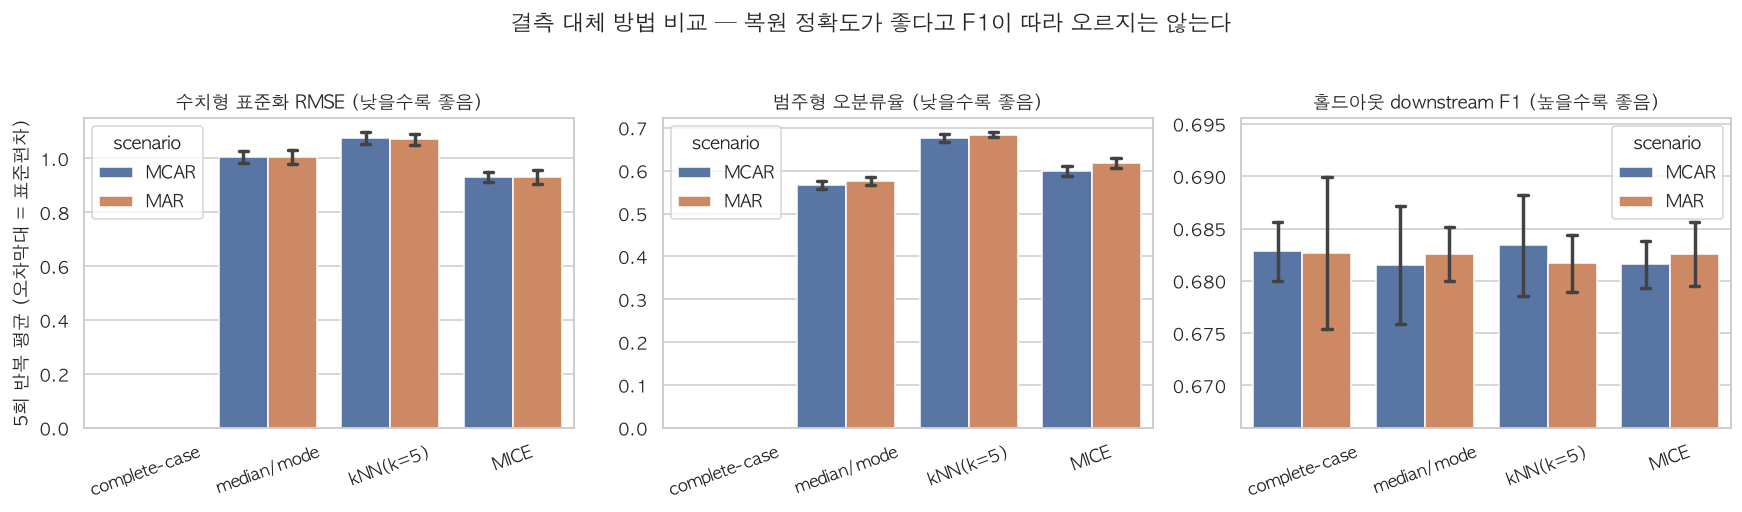

In [12]:
METHOD_ORDER = ["complete-case", "median/mode", "kNN(k=5)", "MICE"]
panels = [
    ("rmse_std", "수치형 표준화 RMSE (낮을수록 좋음)"),
    ("cat_error", "범주형 오분류율 (낮을수록 좋음)"),
    ("downstream_f1", "홀드아웃 downstream F1 (높을수록 좋음)"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (metric, title) in zip(axes, panels, strict=True):
    sns.barplot(
        bench_result, x="method", y=metric, hue="scenario",
        order=METHOD_ORDER, errorbar="sd", capsize=0.15, ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=20)

# F1은 방법 간 차이가 작아서 0부터 그리면 아무 차이도 안 보인다.
f1_values = bench_result["downstream_f1"]
axes[2].set_ylim(f1_values.min() - 0.005, f1_values.max() + 0.005)
axes[0].set_ylabel(f"{N_REPS}회 반복 평균 (오차막대 = 표준편차)")

fig.suptitle("결측 대체 방법 비교 — 복원 정확도가 좋다고 F1이 따라 오르지는 않는다", y=1.03)
show_figure(fig, "03_imputation_benchmark")

### 반복 쌍대 비교

평균만 보면 우연한 시드 차이와 실제 차이를 구분할 수 없다. 같은 마스크(rep)에서 두 방법을
직접 짝지어 비교하고, 몇 번 중 몇 번 이겼는지를 함께 본다.

In [13]:
# --------------------------------------------------
# 함수명 : paired_comparison
# 목적   : 같은 rep·시나리오에서 두 방법의 지표 차이와 승패를 집계
# 매개변수: result(pd.DataFrame) - rep 단위 결과 / metric(str) - 비교 지표
#           left(str)/right(str) - 비교할 두 방법 / lower_is_better(bool) - 낮을수록 좋은 지표인지
# 반환값 : pd.DataFrame - 시나리오별 평균 차이와 승리 횟수
# --------------------------------------------------
def paired_comparison(
    result: pd.DataFrame, metric: str, left: str, right: str, lower_is_better: bool
) -> pd.DataFrame:
    wide = result.pivot_table(index=["scenario", "rep"], columns="method", values=metric)
    diff = wide[left] - wide[right]
    wins = diff < 0 if lower_is_better else diff > 0
    return pd.DataFrame({
        "metric": metric,
        "comparison": f"{left} - {right}",
        "mean_diff": diff.groupby("scenario").mean().round(4),
        "sd_diff": diff.groupby("scenario").std().round(4),
        f"{left}_wins": wins.groupby("scenario").sum().astype(int).astype(str)
        + f"/{result['rep'].nunique()}",
    }).reset_index()


paired_checks = pd.concat([
    paired_comparison(bench_result, "rmse_std", "MICE", "median/mode", lower_is_better=True),
    paired_comparison(bench_result, "cat_error", "MICE", "median/mode", lower_is_better=True),
    paired_comparison(bench_result, "downstream_f1", "MICE", "median/mode",
                      lower_is_better=False),
    paired_comparison(bench_result, "downstream_f1", "median/mode", "complete-case",
                      lower_is_better=False),
], ignore_index=True)
paired_checks

,scenario,metric,comparison,mean_diff,sd_diff,MICE_wins,median/mode_wins
0,MAR,rmse_std,MICE - median/mode,-0.0751,0.0055,5/5,NaN
1,MCAR,rmse_std,MICE - median/mode,-0.0735,0.0066,5/5,NaN
2,MAR,cat_error,MICE - median/mode,0.0416,0.0038,0/5,NaN
3,MCAR,cat_error,MICE - median/mode,0.0332,0.0040,0/5,NaN
4,MAR,downstream_f1,MICE - median/mode,0.0001,0.0032,2/5,NaN
5,MCAR,downstream_f1,MICE - median/mode,0.0001,0.0047,2/5,NaN
6,MAR,downstream_f1,median/mode - complete-case,-0.0001,0.0090,NaN,1/5
7,MCAR,downstream_f1,median/mode - complete-case,-0.0013,0.0056,NaN,1/5


### 고전 방법 실험에서 확인한 것

- MICE는 **수치형 표준화 RMSE**에서 중앙값 대체보다 MCAR·MAR 모두 일관되게 우세하다.
- **범주형에서는 반대다.** 서수 인코딩 후 반올림하는 MICE 근사가 최빈값 대체보다 오히려
  나쁘다. 서수 코드에는 순서 의미가 없는데 반올림이 그 순서를 가정해버리기 때문이다.
- **downstream F1은 방법 간 차이가 반복 표준편차 수준**에 그친다. 즉 복원 오차가 낮다고
  최종 예측 성능이 따라 좋아지지는 않았다.
- 완전제거도 이 실험 조건(전체의 15%만 마스킹, 표본 6,000행)에서는 F1이 크게 떨어지지
  않는다. 다만 이는 **마스크가 설계상 MCAR/약한 MAR**이라서이고, 3절에서 본 실제 결측은
  그 조건을 만족하지 않는다.
- 따라서 '어떤 대체법이 항상 최고'가 아니라 **지표별로 우위가 갈린다**는 것이 결론이다.

### 참고: 딥러닝 대체법에 대해

원 실험에서는 CACTI-style(마스크드 오토인코더)과 TabNAT-style(조건부 생성형) 축소 구현도
같은 마스크로 비교했고, 복원 지표는 MICE보다 좋아지는 경향이었으나 downstream F1은
오히려 낮은 경우가 많았다.

이 노트북에서는 **재현하지 않는다.** 해당 구현과 딥러닝 의존성(torch)이 이 저장소에 없고,
독립 실행형 노트북이라는 원칙상 외부 산출물 JSON을 읽어오지도 않기 때문이다. 데이터가
수만 행·저차원이고 반복 횟수도 적었으므로, 비용이 큰 방법을 기본 전처리로 채택할 근거는
어차피 부족했다.

## 6. 결측 외에 실험한 전처리: 중복 제거와 윈저화

전처리는 결측 처리만이 아니다. 중복행 제거와 극단값 축소도 **무조건 적용하지 않고**
민감도 실험으로 확인한다.

- 동일 행 24개는 개인 식별자가 없어 오류 중복인지 알 수 없으므로 기본 분석에서 유지
- `hours-per-week`, `capital-gain`을 1%·99% 분위수로 윈저화한 뒤 평균·검정 결과 변화 확인
- IQR 펜스는 **진단용으로만** 쓰고 삭제 규칙으로 쓰지 않음

아래 결과에서 `hours-per-week`·`age`는 윈저화해도 평균이 거의 그대로지만,
`capital-gain`은 평균이 절반 가까이 내려간다. 소수의 큰 값이 평균을 끌어올리고 있다는
뜻이므로, 이 컬럼을 쓰는 분석에서는 극단값 처리 방식을 결과와 함께 밝혀야 한다.

In [14]:
# --------------------------------------------------
# 함수명 : duplicate_ledger
# 목적   : 완전 중복 행을 제거했을 때 주요 통계가 얼마나 흔들리는지 확인
# 매개변수: df(pd.DataFrame) - 원본 데이터
# 반환값 : dict[str, float] - 중복 규모와 제거 전후 통계 차이
# --------------------------------------------------
def duplicate_ledger(df: pd.DataFrame) -> dict[str, float]:
    deduped = df.drop_duplicates()
    return {
        "rows": len(df),
        "exact_duplicate_rows": int(df.duplicated().sum()),
        "rows_after_dedup": len(deduped),
        "high_income_rate_before": float((df["income"] == ">50K").mean()),
        "high_income_rate_after": float((deduped["income"] == ">50K").mean()),
        "age_mean_before": float(df["age"].mean()),
        "age_mean_after": float(deduped["age"].mean()),
        "hours_mean_before": float(df["hours-per-week"].mean()),
        "hours_mean_after": float(deduped["hours-per-week"].mean()),
    }


# --------------------------------------------------
# 함수명 : winsor_sensitivity
# 목적   : 1%/99% 윈저화 전후의 평균·표준편차·IQR 이상치 규모를 비교
# 매개변수: df(pd.DataFrame) - 원본 데이터 / columns(list[str]) - 대상 수치 컬럼
# 반환값 : pd.DataFrame - 컬럼별 윈저화 민감도
# --------------------------------------------------
def winsor_sensitivity(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    records = []
    for col in columns:
        series = df[col]
        low, high = series.quantile([0.01, 0.99])
        clipped = series.clip(low, high)
        q1, q3 = series.quantile([0.25, 0.75])
        iqr = q3 - q1
        records.append({
            "column": col,
            "p1": float(low),
            "p99": float(high),
            "mean_before": float(series.mean()),
            "mean_after": float(clipped.mean()),
            "std_before": float(series.std()),
            "std_after": float(clipped.std()),
            "iqr_fence_outliers": int(
                ((series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)).sum()
            ),
        })
    return pd.DataFrame(records)


duplicate_table = pd.Series(duplicate_ledger(train_raw), name="중복 제거 민감도")
print(duplicate_table.to_string())
print()
print("1%/99% 윈저화 민감도")
winsor_sensitivity(train_raw, ["hours-per-week", "capital-gain", "age"]).round(4)

rows                       32561.000000
exact_duplicate_rows          24.000000
rows_after_dedup           32537.000000
high_income_rate_before        0.240810
high_income_rate_after         0.240926
age_mean_before               38.581647
age_mean_after                38.585549
hours_mean_before             40.437456
hours_mean_after              40.440329

1%/99% 윈저화 민감도


,column,p1,p99,mean_before,mean_after,std_before,std_after,iqr_fence_outliers
0,hours-per-week,8.0,80.0,40.4375,40.3904,12.3474,11.9392,9008
1,capital-gain,0.0,15024.0,1077.6488,633.8114,7385.2921,2521.1043,2712
2,age,17.0,74.0,38.5816,38.5283,13.6404,13.4810,143


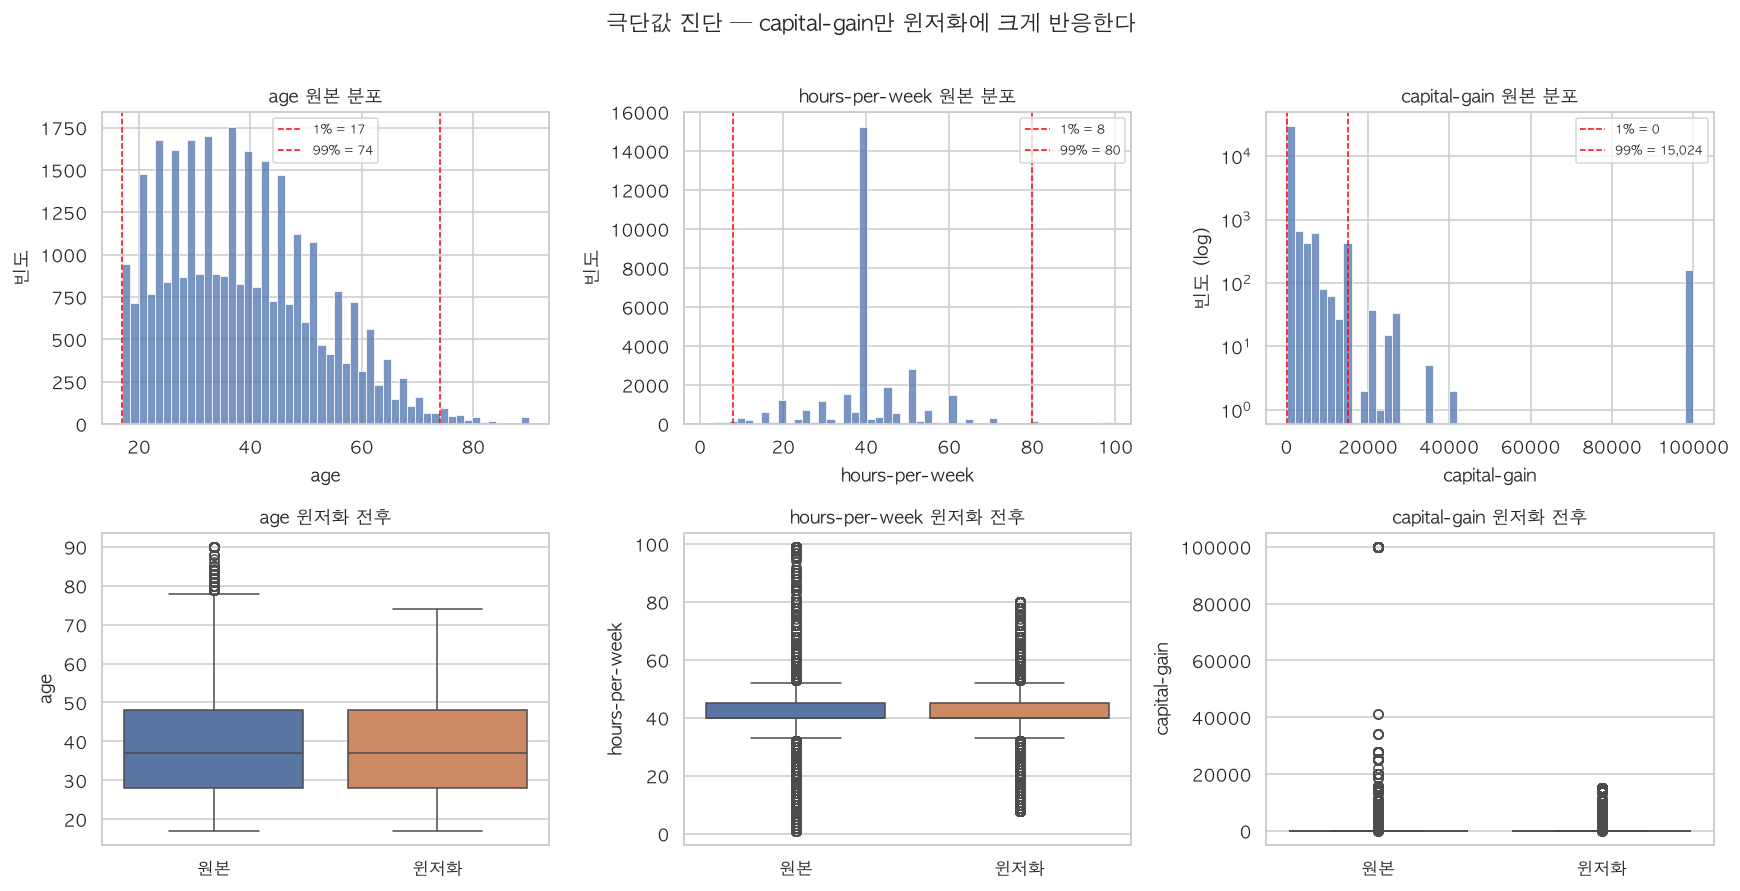

In [15]:
outlier_cols = ["age", "hours-per-week", "capital-gain"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for j, col in enumerate(outlier_cols):
    series = train_raw[col]
    low, high = series.quantile([0.01, 0.99])

    # 위: 분포와 1%/99% 경계
    top = axes[0, j]
    sns.histplot(series, bins=50, ax=top, color="#4C72B0")
    top.axvline(low, color="red", ls="--", lw=1, label=f"1% = {low:,.0f}")
    top.axvline(high, color="red", ls="--", lw=1, label=f"99% = {high:,.0f}")
    top.set_title(f"{col} 원본 분포")
    top.set_ylabel("빈도")
    top.legend(fontsize=8)
    if col == "capital-gain":
        # 0이 압도적이라 선형 축으로는 꼬리가 안 보인다.
        top.set_yscale("log")
        top.set_ylabel("빈도 (log)")

    # 아래: 윈저화 전후 박스플롯
    bottom = axes[1, j]
    compare = pd.DataFrame({
        "원본": series,
        "윈저화": series.clip(low, high),
    }).melt(var_name="처리", value_name=col)
    sns.boxplot(compare, x="처리", y=col, ax=bottom, hue="처리", legend=False)
    bottom.set_title(f"{col} 윈저화 전후")
    bottom.set_xlabel("")

fig.suptitle("극단값 진단 — capital-gain만 윈저화에 크게 반응한다", y=1.01)
show_figure(fig, "04_outlier_winsor")

## 7. 요청한 공유 전처리: 결측행 완전제거

각 split에서 **15개 컬럼 중 하나라도 결측이면 그 행 전체를 삭제**한다.
이를 listwise deletion 또는 complete-case analysis라고 한다.

- 결측값 대체 없음
- 수치형 표준화 없음
- 범주형 인코딩 없음
- 중복 제거 없음
- 극단값 제거·윈저화 없음
- `fnlwgt`를 포함한 원래 15개 컬럼 유지
- train/test는 합치지 않고 원래 구분 유지

In [16]:
train_dropna = train_raw.dropna(axis=0, how="any").reset_index(drop=True)
test_dropna = test_raw.dropna(axis=0, how="any").reset_index(drop=True)

dropna_summary = pd.DataFrame({
    "split": ["train", "test"],
    "rows_before": [len(train_raw), len(test_raw)],
    "rows_after": [len(train_dropna), len(test_dropna)],
    "rows_removed": [len(train_raw) - len(train_dropna), len(test_raw) - len(test_dropna)],
    "removed_pct": [
        round((1 - len(train_dropna) / len(train_raw)) * 100, 2),
        round((1 - len(test_dropna) / len(test_raw)) * 100, 2),
    ],
    "missing_cells_after": [
        int(train_dropna.isna().sum().sum()),
        int(test_dropna.isna().sum().sum()),
    ],
})
dropna_summary

,split,rows_before,rows_after,rows_removed,removed_pct,missing_cells_after
0,train,32561,30162,2399,7.37,0
1,test,16281,15060,1221,7.50,0


In [17]:
assert train_dropna.shape == (30162, 15)
assert test_dropna.shape == (15060, 15)
assert train_dropna.isna().sum().sum() == 0
assert test_dropna.isna().sum().sum() == 0
assert list(train_dropna.columns) == COLS == list(test_dropna.columns)
train_dropna.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 8. 완전제거 전후 표본 변화

3절 진단에서 occupation 결측 여부가 관측 변수로 예측되었다. 즉 MCAR 가정과 양립하기 어려운
증거가 있으므로, 결측행 제거 후 표본의 구성과 통계가 달라질 수 있다.
아래 표는 삭제 전후 변화를 확인하기 위한 **진단**이며 데이터를 다시 수정하지는 않는다.

In [18]:
# --------------------------------------------------
# 함수명 : distribution_snapshot
# 목적   : 표본 구성 변화를 볼 수 있는 핵심 통계 몇 개를 뽑음
# 매개변수: df(pd.DataFrame) - 대상 데이터 / label(str) - 표에 남길 이름
# 반환값 : dict[str, float] - 요약 통계
# --------------------------------------------------
def distribution_snapshot(df: pd.DataFrame, label: str) -> dict[str, float | str]:
    return {
        "dataset": label,
        "n": len(df),
        "age_mean": float(df["age"].mean()),
        "hours_mean": float(df["hours-per-week"].mean()),
        "high_income_rate": float((df["income"] == ">50K").mean()),
        "male_rate": float((df["sex"] == "Male").mean()),
    }


distribution_shift = pd.DataFrame([
    distribution_snapshot(train_raw, "train_before"),
    distribution_snapshot(train_dropna, "train_after_dropna"),
    distribution_snapshot(test_raw, "test_before"),
    distribution_snapshot(test_dropna, "test_after_dropna"),
])
distribution_shift.round(4)

,dataset,n,age_mean,hours_mean,high_income_rate,male_rate
0,train_before,32561,38.5816,40.4375,0.2408,0.6692
1,train_after_dropna,30162,38.4379,40.9312,0.2489,0.6757
2,test_before,16281,38.7675,40.3922,0.2362,0.6670
3,test_after_dropna,15060,38.7683,40.9516,0.2457,0.6738


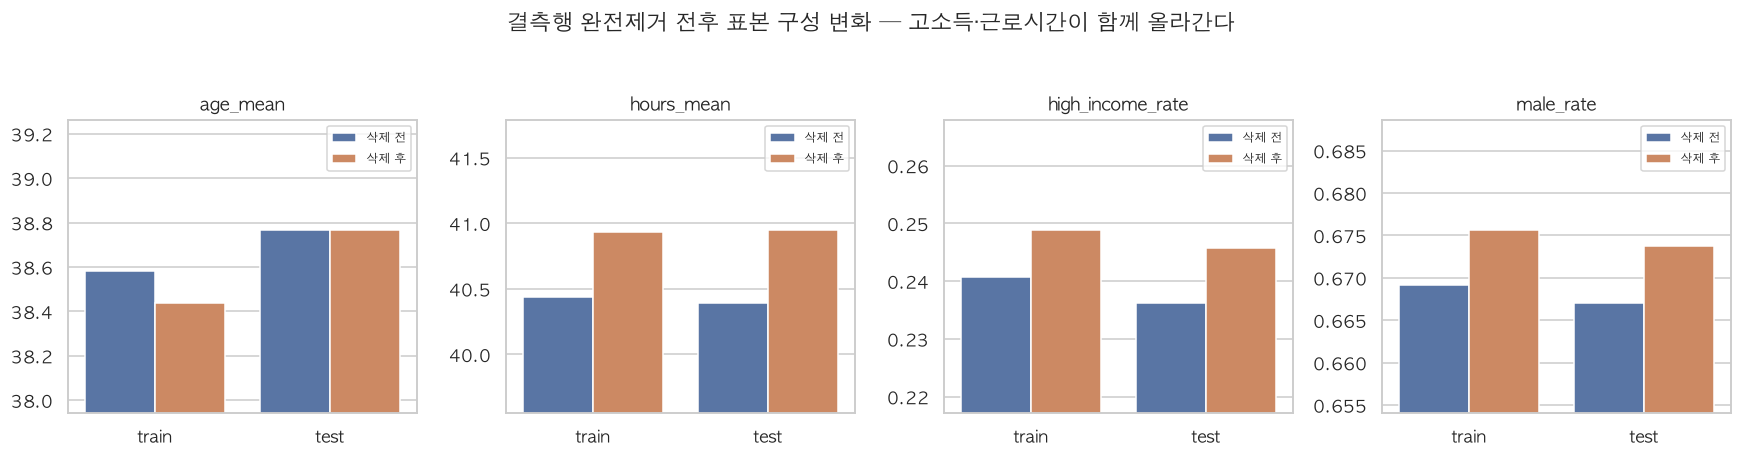

In [19]:
shift_long = distribution_shift.assign(
    split=lambda d: d["dataset"].str.split("_").str[0],
    stage=lambda d: np.where(d["dataset"].str.contains("after"), "삭제 후", "삭제 전"),
).melt(
    id_vars=["split", "stage"],
    value_vars=["age_mean", "hours_mean", "high_income_rate", "male_rate"],
    var_name="metric", value_name="value",
)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, metric in zip(axes, ["age_mean", "hours_mean", "high_income_rate", "male_rate"],
                      strict=True):
    subset = shift_long[shift_long["metric"] == metric]
    sns.barplot(subset, x="split", y="value", hue="stage", ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.set_ylabel("")
    # 변화폭이 작으므로 관측 범위로 축을 좁혀야 차이가 보인다.
    span = subset["value"].max() - subset["value"].min()
    ax.set_ylim(subset["value"].min() - span * 1.5 - 1e-6,
                subset["value"].max() + span * 1.5 + 1e-6)
    ax.legend(fontsize=8)

fig.suptitle("결측행 완전제거 전후 표본 구성 변화 — 고소득·근로시간이 함께 올라간다", y=1.04)
show_figure(fig, "05_dropna_distribution_shift")

## 9. 공유본에서 중복과 극단값 유지 확인

이번 전처리는 **결측행만 제거**한다. 개인 식별자가 없는 동일 행은 임의로 삭제하지 않으며,
통계적 극단값도 오류라는 근거가 없으므로 그대로 둔다.
`capital-gain=99999`, `hours-per-week=99`, 고연령 값도 보존된다.

In [20]:
policy_check = pd.DataFrame({
    "split": ["train", "test"],
    "exact_duplicates_retained": [
        int(train_dropna.duplicated().sum()),
        int(test_dropna.duplicated().sum()),
    ],
    "capital_gain_99999_retained": [
        int((train_dropna["capital-gain"] == 99999).sum()),
        int((test_dropna["capital-gain"] == 99999).sum()),
    ],
    "hours_per_week_99_retained": [
        int((train_dropna["hours-per-week"] == 99).sum()),
        int((test_dropna["hours-per-week"] == 99).sum()),
    ],
    "age_90_retained": [
        int((train_dropna["age"] >= 90).sum()),
        int((test_dropna["age"] >= 90).sum()),
    ],
})
policy_check

,split,exact_duplicates_retained,capital_gain_99999_retained,hours_per_week_99_retained,age_90_retained
0,train,23,148,78,35
1,test,5,81,45,11


## 10. Train/Test CSV 저장

결측행 제거본을 UTF-8 CSV 두 개로 저장하고 하나의 ZIP으로 묶는다.
인덱스는 분석 변수가 아니므로 파일에 쓰지 않는다. 산출물은 `.gitignore` 대상인
`outputs/` 아래에 둔다.

In [21]:
DROPNA_DIR = OUTPUT_DIR / "dropna"
DROPNA_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_PATH = DROPNA_DIR / "adult_train_dropna.csv"
TEST_PATH = DROPNA_DIR / "adult_test_dropna.csv"
ZIP_PATH = DROPNA_DIR / "adult_dropna_train_test.zip"

train_dropna.to_csv(TRAIN_PATH, index=False, encoding="utf-8")
test_dropna.to_csv(TEST_PATH, index=False, encoding="utf-8")

try:
    with zipfile.ZipFile(ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED) as archive:
        archive.write(TRAIN_PATH, arcname=TRAIN_PATH.name)
        archive.write(TEST_PATH, arcname=TEST_PATH.name)
except OSError as exc:
    raise RuntimeError(f"ZIP 생성 실패: {exc}") from exc

print("Train:", TRAIN_PATH)
print("Test :", TEST_PATH)
print("ZIP  :", ZIP_PATH)

Train: /Users/donghyeon/skala-workspace/week4/team-analysis/outputs/dropna/adult_train_dropna.csv
Test : /Users/donghyeon/skala-workspace/week4/team-analysis/outputs/dropna/adult_test_dropna.csv
ZIP  : /Users/donghyeon/skala-workspace/week4/team-analysis/outputs/dropna/adult_dropna_train_test.zip


## 11. 저장 결과 검증

파일을 다시 읽어 행·열 수, 결측, 컬럼 순서, 라벨 통일, ZIP 무결성을 확인한다.
SHA-256은 다른 사람에게 전달한 뒤 파일이 바뀌지 않았는지 확인할 때 쓴다.

In [22]:
# --------------------------------------------------
# 함수명 : file_sha256
# 목적   : 전달 후 무결성 확인용 SHA-256 해시 계산
# 매개변수: path(Path) - 대상 파일
# 반환값 : str - 16진 해시 문자열
# --------------------------------------------------
def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:  # 큰 파일을 한 번에 올리지 않도록 청크로 읽는다.
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


saved_train = pd.read_csv(TRAIN_PATH)
saved_test = pd.read_csv(TEST_PATH)

assert saved_train.shape == (30162, 15)
assert saved_test.shape == (15060, 15)
assert saved_train.isna().sum().sum() == 0
assert saved_test.isna().sum().sum() == 0
assert list(saved_train.columns) == COLS == list(saved_test.columns)
assert set(saved_train["income"]) == {"<=50K", ">50K"}
assert set(saved_test["income"]) == {"<=50K", ">50K"}

with zipfile.ZipFile(ZIP_PATH) as archive:
    assert archive.testzip() is None
    assert set(archive.namelist()) == {TRAIN_PATH.name, TEST_PATH.name}

verification = pd.DataFrame({
    "file": [TRAIN_PATH.name, TEST_PATH.name, ZIP_PATH.name],
    "bytes": [TRAIN_PATH.stat().st_size, TEST_PATH.stat().st_size, ZIP_PATH.stat().st_size],
    "sha256": [file_sha256(TRAIN_PATH), file_sha256(TEST_PATH), file_sha256(ZIP_PATH)],
})
verification

,file,bytes,sha256
0,adult_train_dropna.csv,3298040,1ee178beba351488009b89f6f8e5649fb69054f40be9b0...
1,adult_test_dropna.csv,1646662,723f748dd2eeab7caa34aa4d47eceeeee7a606d7fe4b07...
2,adult_dropna_train_test.zip,581062,23b95504f82fcaf8cb17e4216730fa7db2005c8238d764...


## 12. 최종 선택 — 실제 예측 모델의 전처리

완전제거 데이터는 이번 공유 요청에 맞춘 산출물이다. 반면 **주 모델은 결측행을 삭제하지
않는다.** 누수를 막기 위해 scikit-learn Pipeline 내부에서 다음 처리를 각 교차검증 train
폴드에만 적합한다.

- 입력 변수: 수치형 5개 + 범주형 8개
- 제외 변수: `fnlwgt` (표본 가중치라 개인의 소득과 인과적 관련이 없다)
- 수치형: train 중앙값 대체 → `StandardScaler`
- 범주형: train 최빈값 대체 → `OneHotEncoder(handle_unknown="ignore")`
- 트리 계열 비교 모델: 수치형은 원단위 통과, 범주형은 `OrdinalEncoder`로 변환하며
  결측은 -2, 신규 범주는 -1로 인코딩

SimpleImputer가 모든 복원 지표에서 최고여서 선택된 것은 아니다. 5절에서 봤듯 MICE는
수치형 RMSE가 더 낮았지만 범주형 근사가 나빴고 downstream F1의 우위는 일관되지 않았다.
**해석 가능한 로지스틱 회귀의 안정적·재현 가능한 기본 Pipeline**이라는 목적에 맞춰
중앙값·최빈값 대체를 쓴다.

아래 셀은 전체 train에 전처리기를 적합했을 때의 통계와 출력 차원을 확인한다.
교차검증에서는 Pipeline이 이 적합 과정을 폴드마다 다시 수행한다.

In [23]:
ML_NUM_FEATURES = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
ML_CAT_FEATURES = [
    "workclass", "education", "marital-status", "occupation",
    "relationship", "race", "sex", "native-country",
]
FEATURES = ML_NUM_FEATURES + ML_CAT_FEATURES  # fnlwgt는 표본 가중치라 제외한다.


# --------------------------------------------------
# 함수명 : build_linear_preprocessor
# 목적   : 선형 모델용 전처리기(중앙값·최빈값 대체 → 표준화·원핫) 구성
# 매개변수: 없음
# 반환값 : ColumnTransformer - 폴드마다 다시 적합되는 전처리기
# --------------------------------------------------
def build_linear_preprocessor() -> ColumnTransformer:
    return ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), ML_NUM_FEATURES),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), ML_CAT_FEATURES),
    ])


# --------------------------------------------------
# 함수명 : build_tree_preprocessor
# 목적   : 트리 모델용 전처리기(수치 원단위 통과, 범주 서수 인코딩) 구성
# 매개변수: 없음
# 반환값 : ColumnTransformer - 결측을 -2, 신규 범주를 -1로 인코딩하는 전처리기
# --------------------------------------------------
def build_tree_preprocessor() -> ColumnTransformer:
    return ColumnTransformer([
        ("num", "passthrough", ML_NUM_FEATURES),
        ("cat", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-2,  # 트리는 결측을 별도 분기로 학습할 수 있다.
        ), ML_CAT_FEATURES),
    ])


x_train = train_raw[FEATURES]
x_test = test_raw[FEATURES]

linear_prep = build_linear_preprocessor()
matrix_train = linear_prep.fit_transform(x_train)
matrix_test = linear_prep.transform(x_test)

num_pipe = linear_prep.named_transformers_["num"]
cat_pipe = linear_prep.named_transformers_["cat"]
linear_summary = {
    "excluded_feature": "fnlwgt",
    "numeric_medians": dict(zip(
        ML_NUM_FEATURES, num_pipe.named_steps["imputer"].statistics_, strict=True
    )),
    "categorical_modes": dict(zip(
        ML_CAT_FEATURES, cat_pipe.named_steps["imputer"].statistics_, strict=True
    )),
    "train_matrix_shape": matrix_train.shape,
    "test_matrix_shape": matrix_test.shape,
    "output_feature_count": len(linear_prep.get_feature_names_out()),
}

tree_prep = build_tree_preprocessor()
tree_train = np.asarray(tree_prep.fit_transform(x_train), dtype=float)
tree_test = np.asarray(tree_prep.transform(x_test), dtype=float)
tree_summary = {
    "train_matrix_shape": tree_train.shape,
    "test_matrix_shape": tree_test.shape,
    "encoded_missing_cells_train": int((tree_train == -2).sum()),
    "encoded_missing_cells_test": int((tree_test == -2).sum()),
    "encoded_unknown_cells_test": int((tree_test == -1).sum()),
}

{"linear_pipeline": linear_summary, "tree_pipeline": tree_summary}

{'linear_pipeline': {'excluded_feature': 'fnlwgt',
  'numeric_medians': {'age': np.float64(37.0),
   'education-num': np.float64(10.0),
   'capital-gain': np.float64(0.0),
   'capital-loss': np.float64(0.0),
   'hours-per-week': np.float64(40.0)},
  'categorical_modes': {'workclass': 'Private',
   'education': 'HS-grad',
   'marital-status': 'Married-civ-spouse',
   'occupation': 'Prof-specialty',
   'relationship': 'Husband',
   'race': 'White',
   'sex': 'Male',
   'native-country': 'United-States'},
  'train_matrix_shape': (32561, 104),
  'test_matrix_shape': (16281, 104),
  'output_feature_count': 104},
 'tree_pipeline': {'train_matrix_shape': (32561, 13),
  'test_matrix_shape': (16281, 13),
  'encoded_missing_cells_train': 4262,
  'encoded_missing_cells_test': 2203,
  'encoded_unknown_cells_test': 0}}

### 최종 Pipeline을 실제로 학습해 확인

전처리기만 확인하고 끝내면 누수 없이 굴러가는지 알 수 없다. 로지스틱 회귀를 붙여
train에서 교차검증하고, `adult.test`로 **한 번만** 최종 평가한다.

In [24]:
final_pipeline = Pipeline([
    ("prep", build_linear_preprocessor()),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
])

y_train = (train_raw["income"] == ">50K").astype(int)
y_test = (test_raw["income"] == ">50K").astype(int)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_f1 = cross_val_score(final_pipeline, x_train, y_train, cv=cv, scoring="f1")

final_pipeline.fit(x_train, y_train)
test_pred = final_pipeline.predict(x_test)
test_proba = final_pipeline.predict_proba(x_test)[:, 1]

final_scores = pd.Series({
    "cv_f1_mean": cv_f1.mean(),
    "cv_f1_sd": cv_f1.std(ddof=1),
    "test_f1": f1_score(y_test, test_pred),
    "test_roc_auc": roc_auc_score(y_test, test_proba),
    "test_majority_baseline_acc": float((y_test == 0).mean()),
}, name="최종 로지스틱 Pipeline").round(4)
final_scores

cv_f1_mean                    0.6586
cv_f1_sd                      0.0092
test_f1                       0.6509
test_roc_auc                  0.9036
test_majority_baseline_acc    0.7638
Name: 최종 로지스틱 Pipeline, dtype: float64

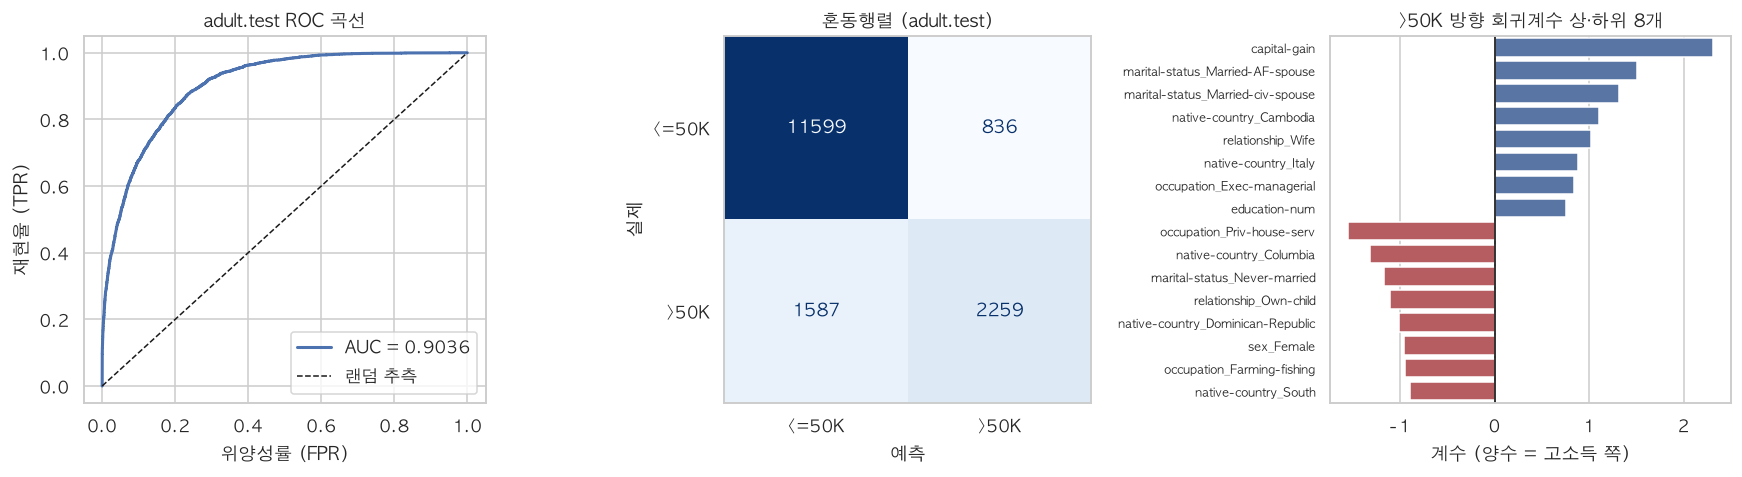

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ROC 곡선
test_fpr, test_tpr, _ = roc_curve(y_test, test_proba)
axes[0].plot(test_fpr, test_tpr, lw=2,
             label=f"AUC = {roc_auc_score(y_test, test_proba):.4f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="랜덤 추측")
axes[0].set_title("adult.test ROC 곡선")
axes[0].set_xlabel("위양성률 (FPR)")
axes[0].set_ylabel("재현율 (TPR)")
axes[0].legend(loc="lower right")

# 혼동행렬 — 실제 개수로 보여야 불균형이 드러난다.
ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred, display_labels=["<=50K", ">50K"],
    cmap="Blues", colorbar=False, ax=axes[1],
)
axes[1].set_title("혼동행렬 (adult.test)")
axes[1].set_xlabel("예측")
axes[1].set_ylabel("실제")
axes[1].grid(False)

# 원핫 계수 상위/하위 — 해석 가능한 모델을 쓴 이유를 보여준다.
coefficients = pd.Series(
    final_pipeline.named_steps["clf"].coef_[0],
    index=final_pipeline.named_steps["prep"].get_feature_names_out(),
)
top_coefficients = pd.concat([coefficients.nlargest(8), coefficients.nsmallest(8)])
labels = top_coefficients.index.str.replace("^(num|cat)__", "", regex=True)
sns.barplot(
    x=top_coefficients.to_numpy(), y=labels.to_numpy(), ax=axes[2],
    hue=(top_coefficients > 0).to_numpy(), palette=["#C44E52", "#4C72B0"], legend=False,
)
axes[2].axvline(0, color="black", lw=1)
axes[2].set_title(">50K 방향 회귀계수 상·하위 8개")
axes[2].set_xlabel("계수 (양수 = 고소득 쪽)")
axes[2].tick_params(axis="y", labelsize=8)

show_figure(fig, "06_final_model_evaluation")

## 13. 최종 정리

| 실험·산출물 | 핵심 처리 | 평가·판단 | 최종 역할 |
|---|---|---|---|
| 결측 보존 원본 | `?`→NaN, 라벨 표기 통일 | 실제 결측 구조와 행 보존 | 진단·EDA의 기본 데이터 |
| 결측 메커니즘 진단 | 결측 지시자 예측 AUC | 0.5를 크게 웃돌아 MCAR 기각 | 삭제 판단의 근거 |
| 완전제거법 | 결측행 전체 삭제 | MCAR이 아니면 선택 편향 위험 | 요청한 공유 CSV·민감도 비교 |
| 중앙값·최빈값 | 주변분포 기반 단순대체 | 빠르고 범주 오분류가 낮지만 관계·분산 왜곡 | **주 모델 Pipeline** |
| kNN(k=5) | 이웃 기반 대체 | 범주 근사 한계, 비용 증가 | 비교 실험 |
| MICE 근사 | 반복 조건부 회귀 | 수치 RMSE 우수, 범주·F1 우위는 일관되지 않음 | 비교 실험 |
| 중복 제거 민감도 | 동일 행 삭제 전후 비교 | 주요 통계 변화 미미, 식별자 없어 유지 | 삭제하지 않음 |
| 1% 윈저화 | 극단값 축소 후 재확인 | hours·age 평균은 거의 불변, capital-gain 평균은 크게 하락 | 민감도만 보고, 원값 유지 |
| 최종 로지스틱 Pipeline | 중앙값·최빈값→표준화·원핫 | 폴드별 fit으로 누수 차단 | 해석 중심 주 모델 |

공유 CSV는 결측이 없어서 바로 쓸 수 있지만, 3절 결과상 결측이 완전 무작위라고 보기
어려우므로 **완전제거로 인한 선택 편향 가능성을 결과 해석에 명시해야 한다.**
새 모델을 교차검증할 때는 이미 변환된 행렬보다 원자료와 Pipeline을 함께 쓰는 것이 안전하다.